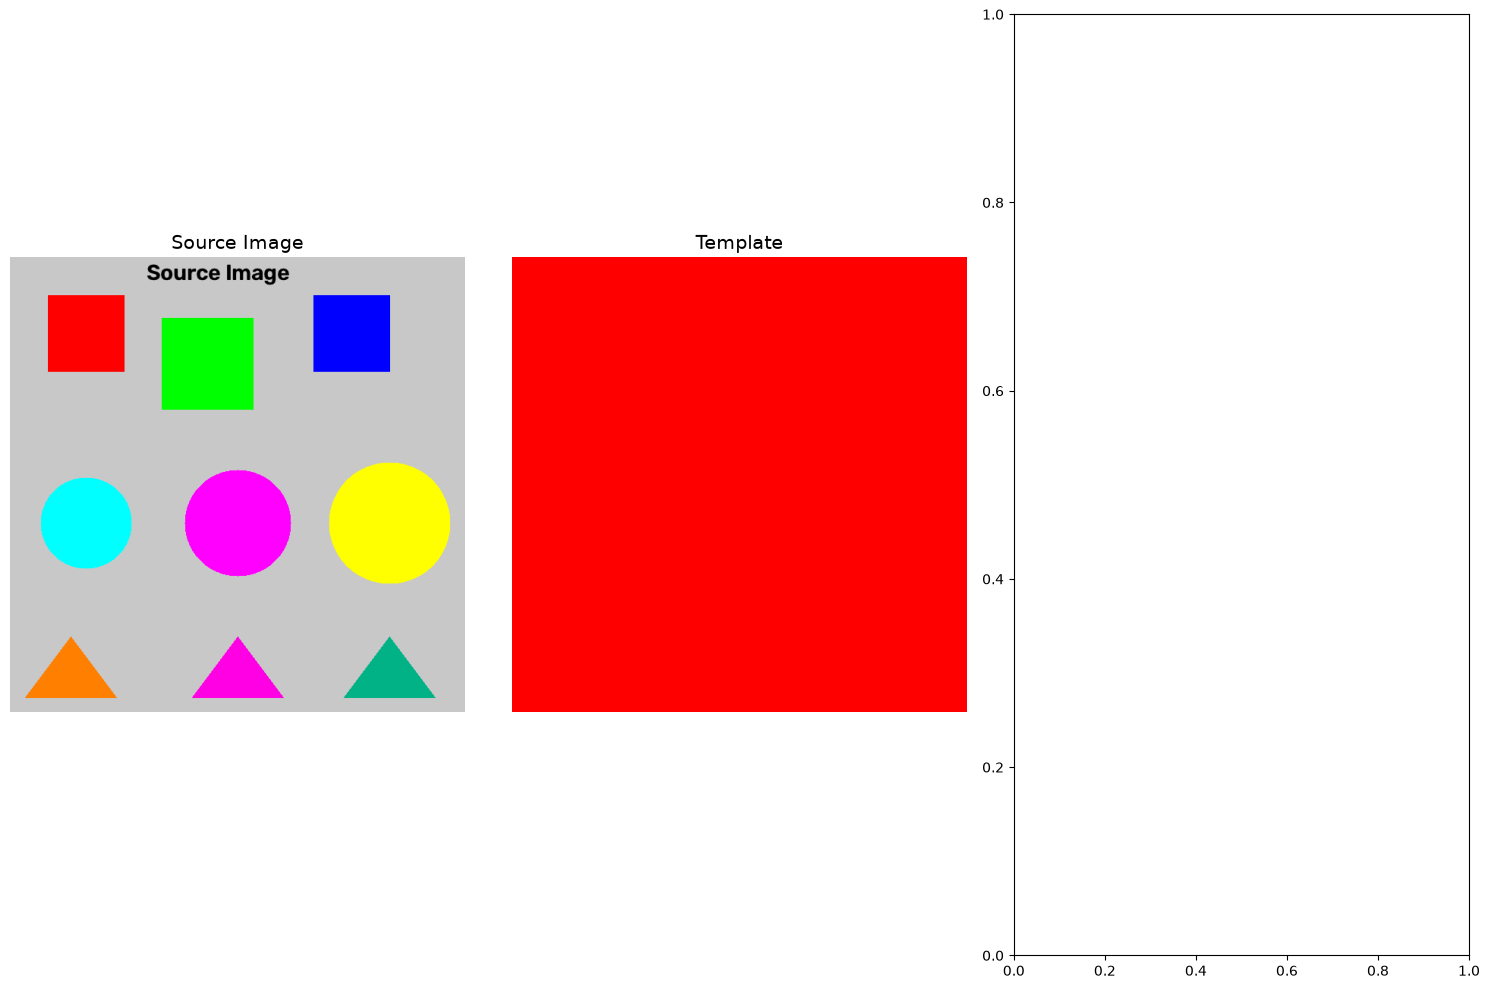

图片已保存，在jupyter Notebook目录下


(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#创建一张 600×600 的灰色背景图
src = np.ones((600, 600, 3), dtype=np.uint8) * 200

#画几个不同颜色的矩形
cv2.rectangle(src, (50, 50), (150, 150), (0, 0, 255), -1)  #红色方块
cv2.rectangle(src, (200, 80), (320, 200), (0, 255, 0), -1)  #绿色方块
cv2.rectangle(src, (400, 50), (500, 150), (255, 0, 0), -1)  #蓝色方块

#画几个圆形
cv2.circle(src, (100, 350), 60, (255, 255, 0), -1)  #黄色圆
cv2.circle(src, (300, 350), 70, (255, 0, 255), -1)  #紫色圆
cv2.circle(src, (500, 350), 80, (0, 255, 255), -1)  #青色圆

#画几个三角形（用多边形）
triangle1 = np.array([[80, 500], [20, 580], [140, 580]], np.int32)
triangle2 = np.array([[300, 500], [240, 580], [360, 580]],np.int32)
triangle3 = np.array([[500, 500], [440, 580], [560, 580]], np.int32)
cv2.fillPoly(src, [triangle1], (0, 128, 255))
cv2.fillPoly(src, [triangle2], (228, 0, 255))
cv2.fillPoly(src, [triangle3], (134, 178, 0))

#添加一些文字标注
cv2.putText(src, 'Source Image', (180, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)


#创建一个模板从大图中截取一个区域
template = src[50:150, 50:150].copy()

fig, axes = plt.subplots(1, 3, figsize=(15,10))
axes[0].imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB))
axes[0].set_title('Source Image', fontsize=14)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))
axes[1].set_title('Template', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

#保存文件
cv2.imwrite('template_match_src.jpg', src)
cv2.imwrite('template_match_template.jpg', template)
print("图片已保存，在jupyter Notebook目录下")


#读取大图和模板小图
img = cv2.imread('template_match_src.jpg')
template = cv2.imread('template_match_template.jpg')
h, w = template.shape[:2]

#使用平方法匹配
result = cv2.matchTemplate(img, template, cv2.TM_SQDIFF)

#获取最佳匹配位置（最小值的位置）
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

#对于 TM_SQDIFF，最小值位置即为匹配点
top_left = min_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

#在原图上画上匹配区域
cv2.rectangle(img, top_left, bottom_right, (0, 0, 255), 2)

axes[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Match result', fontsize=14)
axes[1].axis('off')